# Convolutional Neural Networks (CNN)

## Learning Objectives
- Understand how convolutions work at the mathematical level
- Implement convolution operations manually using NumPy
- Learn about filters, feature maps, and pooling
- Build a CNN from scratch to understand the architecture
- Compare manual implementation with TensorFlow/Keras libraries
- Visualize filters, feature maps, and pooling effects

This notebook teaches CNNs through **manual implementation first**, then **library-based approach** using the same data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import time
from skimage import transform
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✓ All libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")

✓ All libraries imported successfully
NumPy version: 2.4.4
TensorFlow version: 2.21.0


## Part 1: Load and Prepare Data

We'll use MNIST digits (28x28 images) for our CNN learning. This is perfect for understanding convolutions and pooling.

Loading MNIST dataset (this may take a moment)...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✓ Data loaded successfully
Training set shape: (5000, 28, 28) (5000 images, 28x28)
Test set shape: (1000, 28, 28)
Classes: [0 1 2 3 4 5 6 7 8 9]


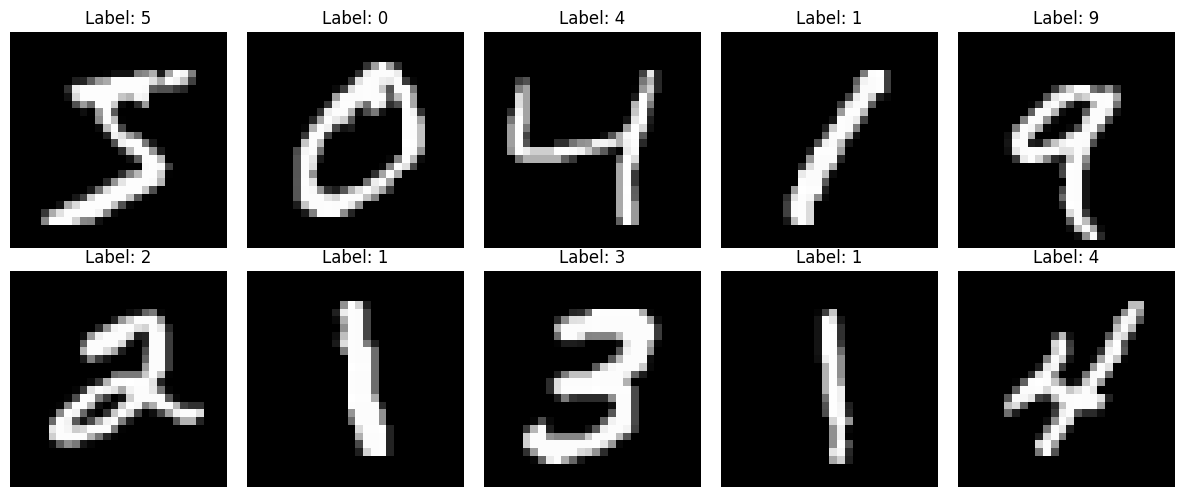

✓ Sample MNIST images displayed


In [2]:
# Load MNIST dataset (70k images, 28x28)
print("Loading MNIST dataset (this may take a moment)...")
from tensorflow.keras.datasets import mnist

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# Use only first 5000 samples for faster training and learning
X_train = X_train_full[:5000]
y_train = y_train_full[:5000]
X_test = X_test_full[:1000]
y_test = y_test_full[:1000]

# Normalize to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"✓ Data loaded successfully")
print(f"Training set shape: {X_train.shape} (5000 images, 28x28)")
print(f"Test set shape: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Sample MNIST images displayed")

## Part 2: Understanding Convolution Operations

### What is a Convolution?

A **convolution** is a mathematical operation that slides a small filter (kernel) across an image and computes the dot product at each position.

**Key Concepts:**
- **Filter/Kernel**: Small matrix (e.g., 3x3, 5x5) of learned weights
- **Feature Map**: Output of applying filter across image (detects patterns)
- **Stride**: How many pixels the filter moves (e.g., stride=1 moves 1 pixel at a time)
- **Padding**: Adding zeros around image borders to preserve size

**Formula for 2D Convolution:**
```
output[i,j] = sum(filter * input_region) + bias
```

Where `input_region` is the portion of image covered by the filter at position (i,j)

### Why Convolutions?
1. **Local Connectivity**: Filters only look at small regions → find edges, textures, shapes
2. **Parameter Sharing**: Same filter used across entire image → fewer parameters
3. **Translation Invariance**: Feature detection is position-independent

EXAMPLE 1: Manual Convolution on Simple 5x5 Image

Original Image (5x5):
[[1. 2. 3. 0. 1.]
 [0. 2. 1. 3. 2.]
 [1. 0. 2. 1. 0.]
 [2. 1. 0. 2. 3.]
 [1. 1. 2. 2. 1.]]

Filter/Kernel (3x3 - Sobel edge detector):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Feature Map after convolution (stride=1, no padding):
Output shape: (3, 3)
[[ 5.  1. -2.]
 [ 1.  4.  0.]
 [-2.  4.  3.]]


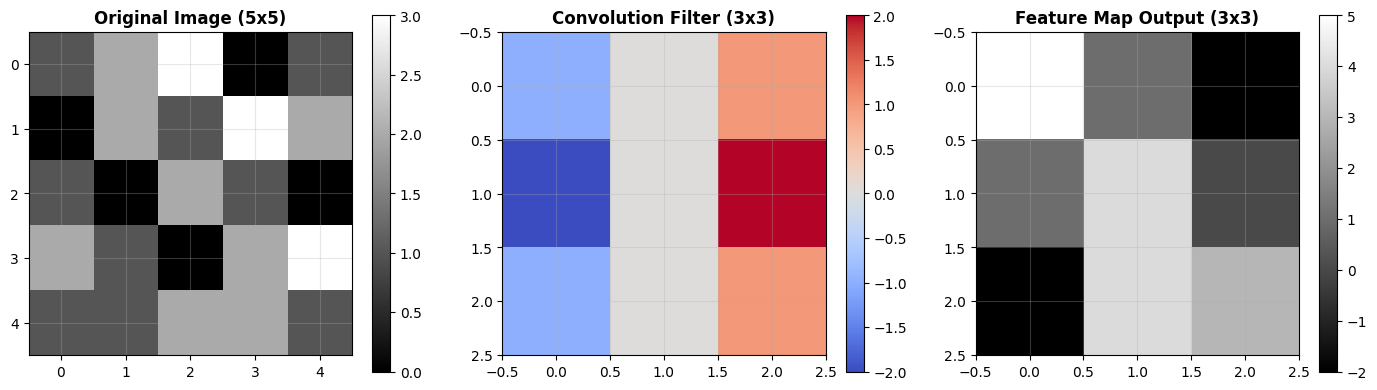


✓ Convolution operation completed


In [3]:
### Manual Implementation: 2D Convolution Operation

def manual_convolution_2d(input_image, filter_kernel, stride=1, padding=0):
    """
    Perform 2D convolution on an image with a given filter.
    
    Args:
        input_image: 2D numpy array (height, width)
        filter_kernel: 2D numpy array (kernel_size, kernel_size)
        stride: Step size for filter movement
        padding: Number of zeros to pad around image
    
    Returns:
        feature_map: 2D output array
    """
    H, W = input_image.shape
    K = filter_kernel.shape[0]  # Kernel size (assuming square)
    
    # Add padding if specified
    if padding > 0:
        input_image = np.pad(input_image, padding, mode='constant', constant_values=0)
        H, W = input_image.shape
    
    # Calculate output dimensions
    out_H = (H - K) // stride + 1
    out_W = (W - K) // stride + 1
    
    # Initialize output feature map
    feature_map = np.zeros((out_H, out_W))
    
    # Slide filter across image
    for i in range(out_H):
        for j in range(out_W):
            # Get the region under the filter
            region = input_image[i*stride:i*stride+K, j*stride:j*stride+K]
            
            # Compute dot product: element-wise multiply and sum
            feature_map[i, j] = np.sum(region * filter_kernel)
    
    return feature_map

# Test with a simple example
print("=" * 60)
print("EXAMPLE 1: Manual Convolution on Simple 5x5 Image")
print("=" * 60)

# Create a simple test image
test_image = np.array([
    [1, 2, 3, 0, 1],
    [0, 2, 1, 3, 2],
    [1, 0, 2, 1, 0],
    [2, 1, 0, 2, 3],
    [1, 1, 2, 2, 1]
], dtype=float)

# Create a simple filter (edge detection)
edge_filter = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

print("\nOriginal Image (5x5):")
print(test_image)
print("\nFilter/Kernel (3x3 - Sobel edge detector):")
print(edge_filter)

# Apply convolution
result = manual_convolution_2d(test_image, edge_filter, stride=1, padding=0)

print(f"\nFeature Map after convolution (stride=1, no padding):")
print(f"Output shape: {result.shape}")
print(result)

# Visualize convolution operation
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im1 = axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original Image (5x5)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(edge_filter, cmap='coolwarm')
axes[1].set_title('Convolution Filter (3x3)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(result, cmap='gray')
axes[2].set_title('Feature Map Output (3x3)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig('convolution_example.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Convolution operation completed")

### Multiple Filters Create Multiple Feature Maps

In CNNs, we use **multiple filters** to detect different features:
- **Filter 1**: Detects horizontal edges
- **Filter 2**: Detects vertical edges
- **Filter 3**: Detects diagonal patterns
- **Filter 4**: Detects corners
- etc.

Each filter produces one **feature map**, and stacking all creates the output of a convolutional layer.


EXAMPLE 2: Multiple Filters on Real MNIST Image


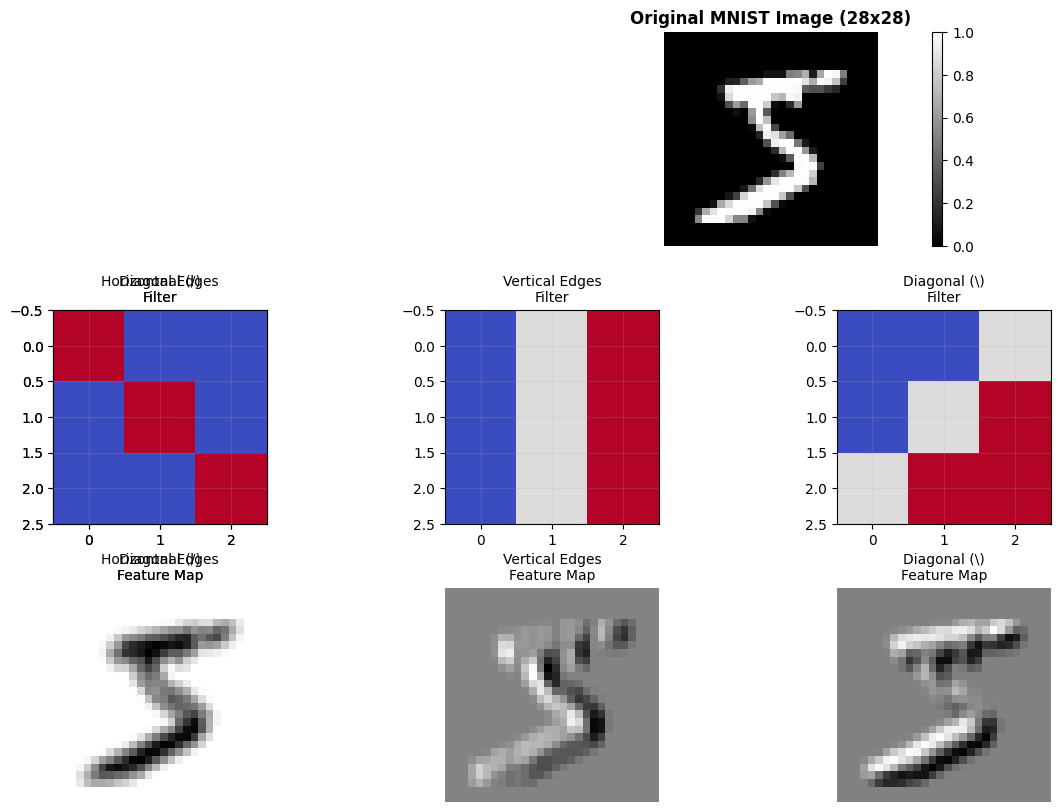


✓ Multiple filters applied to MNIST digit
Observation: Each filter detects different patterns in the image


In [4]:
print("\n" + "=" * 60)
print("EXAMPLE 2: Multiple Filters on Real MNIST Image")
print("=" * 60)

# Take first MNIST image
mnist_image = X_train[0]

# Create multiple filter types
filters = {
    'Horizontal Edges': np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=float),
    'Vertical Edges': np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=float),
    'Diagonal (\\)': np.array([[-1, -1, 0], [-1, 0, 1], [0, 1, 1]], dtype=float),
    'Diagonal (/)': np.array([[0, -1, -1], [-1, 0, -1], [-1, -1, 0]], dtype=float),
}

# Apply all filters
feature_maps = {}
for name, filter_kernel in filters.items():
    feature_maps[name] = manual_convolution_2d(mnist_image, filter_kernel, stride=1, padding=1)

# Visualize
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Original image
ax = fig.add_subplot(gs[0, :])
im = ax.imshow(mnist_image, cmap='gray')
ax.set_title('Original MNIST Image (28x28)', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax)

# Each filter and its output
for idx, (name, fmap) in enumerate(feature_maps.items()):
    # Filter
    ax = fig.add_subplot(gs[1, idx % 3])
    filter_kernel = filters[name]
    im = ax.imshow(filter_kernel, cmap='coolwarm')
    ax.set_title(f'{name}\nFilter', fontsize=10)
    ax.grid(True, alpha=0.2)
    
    # Feature map
    ax = fig.add_subplot(gs[2, idx % 3])
    im = ax.imshow(fmap, cmap='gray')
    ax.set_title(f'{name}\nFeature Map', fontsize=10)
    ax.axis('off')

plt.savefig('multiple_filters_mnist.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Multiple filters applied to MNIST digit")
print("Observation: Each filter detects different patterns in the image")

## Part 3: Understanding Pooling Operations

### What is Pooling?

**Pooling** reduces the spatial dimensions of feature maps while retaining important information.

**Key Benefits:**
1. **Reduces computation**: Smaller feature maps = faster processing
2. **Reduces parameters**: Less data to train
3. **Translation robustness**: Small shifts don't affect features
4. **Focuses on important features**: Keeps strongest signals

**Types of Pooling:**
- **Max Pooling**: Takes the maximum value in each region
- **Average Pooling**: Takes the average value in each region


EXAMPLE 3: Max Pooling vs Average Pooling

Original feature map shape: (28, 28)
Max pooled shape (2x2 pooling, stride=2): (14, 14)
Avg pooled shape (2x2 pooling, stride=2): (14, 14)
Dimension reduction: 28x28 → 14x14


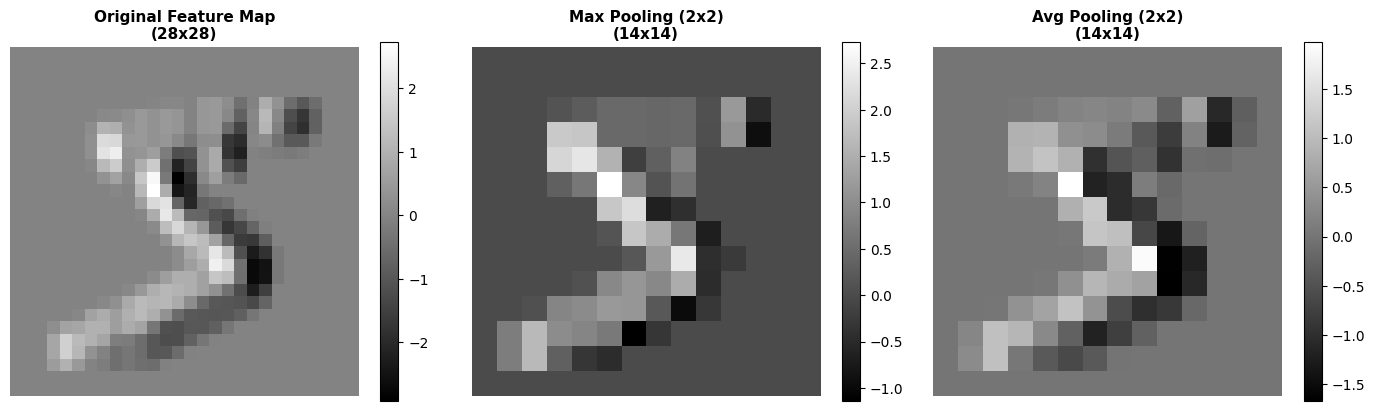


✓ Pooling operations completed
Observation: Max pooling preserves strong activations, avg pooling smooths features


In [5]:
### Manual Implementation: Pooling Operations

def max_pooling_2d(feature_map, pool_size=2, stride=None):
    """
    Apply max pooling to reduce feature map dimensions.
    
    Args:
        feature_map: 2D numpy array
        pool_size: Size of pooling window (e.g., 2x2)
        stride: Step size (default = pool_size for non-overlapping pools)
    
    Returns:
        pooled_map: Smaller feature map with max values
    """
    if stride is None:
        stride = pool_size
    
    H, W = feature_map.shape
    out_H = (H - pool_size) // stride + 1
    out_W = (W - pool_size) // stride + 1
    
    pooled_map = np.zeros((out_H, out_W))
    
    for i in range(out_H):
        for j in range(out_W):
            region = feature_map[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            pooled_map[i, j] = np.max(region)
    
    return pooled_map

def avg_pooling_2d(feature_map, pool_size=2, stride=None):
    """Apply average pooling."""
    if stride is None:
        stride = pool_size
    
    H, W = feature_map.shape
    out_H = (H - pool_size) // stride + 1
    out_W = (W - pool_size) // stride + 1
    
    pooled_map = np.zeros((out_H, out_W))
    
    for i in range(out_H):
        for j in range(out_W):
            region = feature_map[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            pooled_map[i, j] = np.mean(region)
    
    return pooled_map

print("\n" + "=" * 60)
print("EXAMPLE 3: Max Pooling vs Average Pooling")
print("=" * 60)

# Use a feature map from earlier
feature_map = feature_maps['Vertical Edges']

# Apply pooling
max_pool = max_pooling_2d(feature_map, pool_size=2, stride=2)
avg_pool = avg_pooling_2d(feature_map, pool_size=2, stride=2)

print(f"\nOriginal feature map shape: {feature_map.shape}")
print(f"Max pooled shape (2x2 pooling, stride=2): {max_pool.shape}")
print(f"Avg pooled shape (2x2 pooling, stride=2): {avg_pool.shape}")
print(f"Dimension reduction: {feature_map.shape[0]}x{feature_map.shape[1]} → {max_pool.shape[0]}x{max_pool.shape[1]}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im1 = axes[0].imshow(feature_map, cmap='gray')
axes[0].set_title(f'Original Feature Map\n({feature_map.shape[0]}x{feature_map.shape[1]})', 
                  fontsize=11, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(max_pool, cmap='gray')
axes[1].set_title(f'Max Pooling (2x2)\n({max_pool.shape[0]}x{max_pool.shape[1]})', 
                  fontsize=11, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(avg_pool, cmap='gray')
axes[2].set_title(f'Avg Pooling (2x2)\n({avg_pool.shape[0]}x{avg_pool.shape[1]})', 
                  fontsize=11, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig('pooling_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Pooling operations completed")
print("Observation: Max pooling preserves strong activations, avg pooling smooths features")

## Part 4: Activation Functions in CNN

After each convolution, we apply a **non-linear activation function** (usually ReLU) to introduce non-linearity.

**ReLU (Rectified Linear Unit)**: f(x) = max(0, x)
- Replaces negative values with 0
- Keeps positive values unchanged
- Computationally efficient
- Prevents vanishing gradient problem


EXAMPLE 4: ReLU Activation Function

Feature map stats BEFORE ReLU:
  Min value: -2.925
  Max value: 2.725
  Mean value: 0.000
  Negative values count: 127

Feature map stats AFTER ReLU:
  Min value: 0.000
  Max value: 2.725
  Mean value: 0.145
  Negative values count: 0


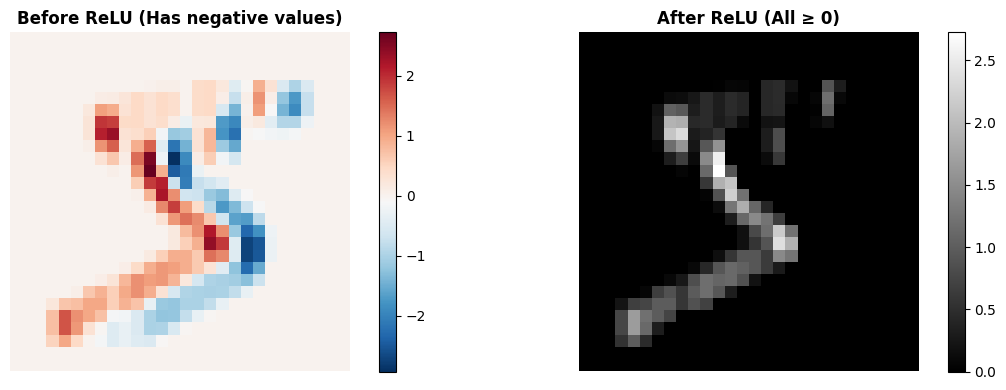


✓ ReLU activation applied


In [6]:
def relu(x):
    """ReLU activation function: max(0, x)"""
    return np.maximum(0, x)

print("\n" + "=" * 60)
print("EXAMPLE 4: ReLU Activation Function")
print("=" * 60)

# Apply ReLU to a feature map
feature_map_before = feature_maps['Vertical Edges']
feature_map_after_relu = relu(feature_map_before)

print(f"\nFeature map stats BEFORE ReLU:")
print(f"  Min value: {feature_map_before.min():.3f}")
print(f"  Max value: {feature_map_before.max():.3f}")
print(f"  Mean value: {feature_map_before.mean():.3f}")
print(f"  Negative values count: {(feature_map_before < 0).sum()}")

print(f"\nFeature map stats AFTER ReLU:")
print(f"  Min value: {feature_map_after_relu.min():.3f}")
print(f"  Max value: {feature_map_after_relu.max():.3f}")
print(f"  Mean value: {feature_map_after_relu.mean():.3f}")
print(f"  Negative values count: {(feature_map_after_relu < 0).sum()}")

# Visualize ReLU effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im1 = axes[0].imshow(feature_map_before, cmap='RdBu_r')
axes[0].set_title('Before ReLU (Has negative values)', fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(feature_map_after_relu, cmap='gray')
axes[1].set_title('After ReLU (All ≥ 0)', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig('relu_activation.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ ReLU activation applied")

## Part 5: Building a Complete Manual CNN Architecture

A typical CNN architecture looks like this:
```
Input (28x28 image)
    ↓
Conv Layer 1 (3x3 filters) → 32 feature maps
    ↓
ReLU activation
    ↓
Max Pooling (2x2) → reduces to 14x14
    ↓
Conv Layer 2 (3x3 filters) → 64 feature maps
    ↓
ReLU activation
    ↓
Max Pooling (2x2) → reduces to 7x7
    ↓
Flatten → 64*7*7 = 3136 neurons
    ↓
Fully Connected Layer → 128 neurons
    ↓
Softmax output → 10 classes (digits 0-9)
```

**Note:** This is simplified for learning. We'll use random filters for demonstration.

In [7]:
class SimpleCNNManual:
    """
    A simple CNN implemented from scratch using NumPy.
    For educational purposes - demonstrates forward pass only.
    """
    def __init__(self, num_filters_layer1=4, num_filters_layer2=8):
        self.num_filters_1 = num_filters_layer1
        self.num_filters_2 = num_filters_layer2
        
        # Initialize random filters (in practice, these are learned)
        np.random.seed(42)
        self.filters_layer1 = np.random.randn(num_filters_layer1, 3, 3) * 0.1
        self.filters_layer2 = np.random.randn(num_filters_layer2, 3, 3) * 0.1
        
    def forward(self, image):
        """Forward pass through the CNN"""
        print(f"Input shape: {image.shape}")
        
        # Conv Layer 1 - apply all filters
        conv1_outputs = []
        for f in self.filters_layer1:
            feature_map = manual_convolution_2d(image, f, stride=1, padding=1)
            feature_map = relu(feature_map)  # ReLU activation
            conv1_outputs.append(feature_map)
        
        conv1_outputs = np.array(conv1_outputs)
        print(f"After Conv Layer 1 + ReLU: {conv1_outputs.shape}")
        
        # Max Pooling Layer 1
        pool1_outputs = []
        for fmap in conv1_outputs:
            pooled = max_pooling_2d(fmap, pool_size=2, stride=2)
            pool1_outputs.append(pooled)
        
        pool1_outputs = np.array(pool1_outputs)
        print(f"After Max Pooling 1: {pool1_outputs.shape}")
        
        # Conv Layer 2 - apply all filters to each pooled feature map
        conv2_outputs = []
        for f in self.filters_layer2:
            combined_fmap = np.zeros(pool1_outputs[0].shape)
            for pmap in pool1_outputs:
                combined_fmap += manual_convolution_2d(pmap, f, stride=1, padding=1)
            combined_fmap = relu(combined_fmap)
            conv2_outputs.append(combined_fmap)
        
        conv2_outputs = np.array(conv2_outputs)
        print(f"After Conv Layer 2 + ReLU: {conv2_outputs.shape}")
        
        # Max Pooling Layer 2
        pool2_outputs = []
        for fmap in conv2_outputs:
            pooled = max_pooling_2d(fmap, pool_size=2, stride=2)
            pool2_outputs.append(pooled)
        
        pool2_outputs = np.array(pool2_outputs)
        print(f"After Max Pooling 2: {pool2_outputs.shape}")
        
        # Flatten
        flattened = pool2_outputs.reshape(1, -1)
        print(f"After Flatten: {flattened.shape}")
        
        return conv1_outputs, pool1_outputs, conv2_outputs, pool2_outputs, flattened

print("\n" + "=" * 60)
print("EXAMPLE 5: Forward Pass Through Manual CNN")
print("=" * 60)

# Create and test the manual CNN
manual_cnn = SimpleCNNManual(num_filters_layer1=4, num_filters_layer2=8)

# Process one MNIST image
test_image = X_train[0]
conv1, pool1, conv2, pool2, flattened = manual_cnn.forward(test_image)

print("\n✓ Forward pass completed successfully")


EXAMPLE 5: Forward Pass Through Manual CNN
Input shape: (28, 28)
After Conv Layer 1 + ReLU: (4, 28, 28)
After Max Pooling 1: (4, 14, 14)
After Conv Layer 2 + ReLU: (8, 14, 14)
After Max Pooling 2: (8, 7, 7)
After Flatten: (1, 392)

✓ Forward pass completed successfully


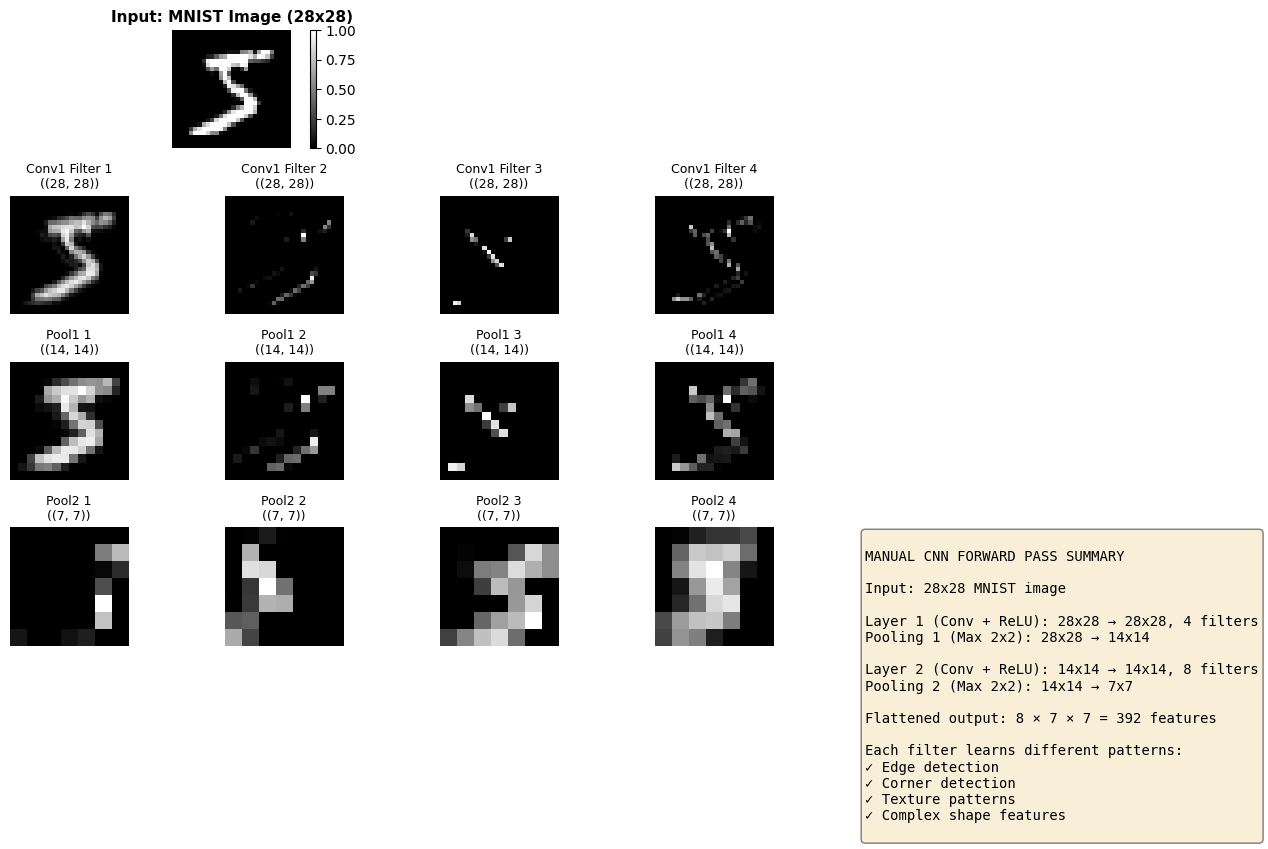


✓ Visualization saved


In [8]:
# Visualize the feature maps at each layer
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(4, 6, figure=fig, hspace=0.4, wspace=0.3)

# Input image
ax = fig.add_subplot(gs[0, :2])
im = ax.imshow(test_image, cmap='gray')
ax.set_title('Input: MNIST Image (28x28)', fontsize=11, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax)

# Conv1 + ReLU outputs (4 feature maps)
for i in range(min(4, len(conv1))):
    ax = fig.add_subplot(gs[1, i])
    im = ax.imshow(conv1[i], cmap='gray')
    ax.set_title(f'Conv1 Filter {i+1}\n({conv1[i].shape})', fontsize=9)
    ax.axis('off')

# Pool1 outputs (4 feature maps)
for i in range(min(4, len(pool1))):
    ax = fig.add_subplot(gs[2, i])
    im = ax.imshow(pool1[i], cmap='gray')
    ax.set_title(f'Pool1 {i+1}\n({pool1[i].shape})', fontsize=9)
    ax.axis('off')

# Pool2 outputs (show first 4)
for i in range(min(4, len(pool2))):
    ax = fig.add_subplot(gs[3, i])
    im = ax.imshow(pool2[i], cmap='gray')
    ax.set_title(f'Pool2 {i+1}\n({pool2[i].shape})', fontsize=9)
    ax.axis('off')

# Add summary text
ax = fig.add_subplot(gs[3, 4:])
summary_text = f"""
MANUAL CNN FORWARD PASS SUMMARY

Input: 28x28 MNIST image

Layer 1 (Conv + ReLU): 28x28 → 28x28, 4 filters
Pooling 1 (Max 2x2): 28x28 → 14x14

Layer 2 (Conv + ReLU): 14x14 → 14x14, 8 filters
Pooling 2 (Max 2x2): 14x14 → 7x7

Flattened output: 8 × 7 × 7 = 392 features

Each filter learns different patterns:
✓ Edge detection
✓ Corner detection
✓ Texture patterns
✓ Complex shape features
"""
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.axis('off')

plt.savefig('cnn_forward_pass_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved")

## Part 6: Using TensorFlow/Keras for CNN Implementation

Now let's build the SAME architecture using TensorFlow/Keras libraries.

**Key Advantages of Libraries:**
1. **Optimized**: GPU acceleration, efficient computation
2. **Automatic Differentiation**: Backpropagation automatically calculated
3. **Training Loops**: Built-in optimization and learning
4. **Parameter Learning**: Filters are trained on data

**Architecture:** Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Flatten → Dense → Softmax

In [9]:
print("\n" + "=" * 60)
print("BUILDING KERAS CNN MODEL")
print("=" * 60)

# Prepare data for Keras (needs 4D: samples, height, width, channels)
X_train_keras = X_train.reshape(-1, 28, 28, 1)
X_test_keras = X_test.reshape(-1, 28, 28, 1)
y_train_keras = keras.utils.to_categorical(y_train, 10)
y_test_keras = keras.utils.to_categorical(y_test, 10)

print(f"\nData shapes for Keras:")
print(f"X_train: {X_train_keras.shape}")
print(f"y_train: {y_train_keras.shape}")
print(f"X_test: {X_test_keras.shape}")
print(f"y_test: {y_test_keras.shape}")

# Build the model
model = keras.Sequential([
    # Conv Layer 1: 4 filters, 3x3 kernel
    layers.Conv2D(4, (3, 3), padding='same', input_shape=(28, 28, 1)),
    layers.Activation('relu'),
    # Max Pooling Layer 1: 2x2 pooling
    layers.MaxPooling2D((2, 2)),
    
    # Conv Layer 2: 8 filters, 3x3 kernel
    layers.Conv2D(8, (3, 3), padding='same'),
    layers.Activation('relu'),
    # Max Pooling Layer 2: 2x2 pooling
    layers.MaxPooling2D((2, 2)),
    
    # Flatten to 1D
    layers.Flatten(),
    
    # Fully Connected Layer
    layers.Dense(128, activation='relu'),
    
    # Output Layer: 10 classes (digits 0-9)
    layers.Dense(10, activation='softmax')
])

# Display model architecture
print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✓ Model created and compiled successfully")


BUILDING KERAS CNN MODEL

Data shapes for Keras:
X_train: (5000, 28, 28, 1)
y_train: (5000, 10)
X_test: (1000, 28, 28, 1)
y_test: (1000, 10)

MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 392)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,930 (202.85 KB)

 Trainable params: 51,930 (202.85 KB)

 Non-trainable params: 0 (0.00 B)


✓ Model created and compiled successfully


In [10]:
print("\n" + "=" * 60)
print("TRAINING THE CNN MODEL")
print("=" * 60)

# Train the model
start_time = time.time()
history = model.fit(
    X_train_keras, y_train_keras,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
training_time = time.time() - start_time

print(f"\n✓ Training completed in {training_time:.2f} seconds")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_keras, y_test_keras, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


TRAINING THE CNN MODEL
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7408 - loss: 0.9230 - val_accuracy: 0.8840 - val_loss: 0.4002
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9090 - loss: 0.3241 - val_accuracy: 0.9020 - val_loss: 0.3377
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9312 - loss: 0.2410 - val_accuracy: 0.9220 - val_loss: 0.2924
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9473 - loss: 0.1864 - val_accuracy: 0.9350 - val_loss: 0.2546
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9575 - loss: 0.1491 - val_accuracy: 0.9390 - val_loss: 0.2219
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9647 - loss: 0.1208 - val_accuracy: 0.9440 - val_loss: 0.1976
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9718 - loss: 0.1007 - val_accuracy: 0.9470 - val_loss: 0.1813
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9745 - loss: 0

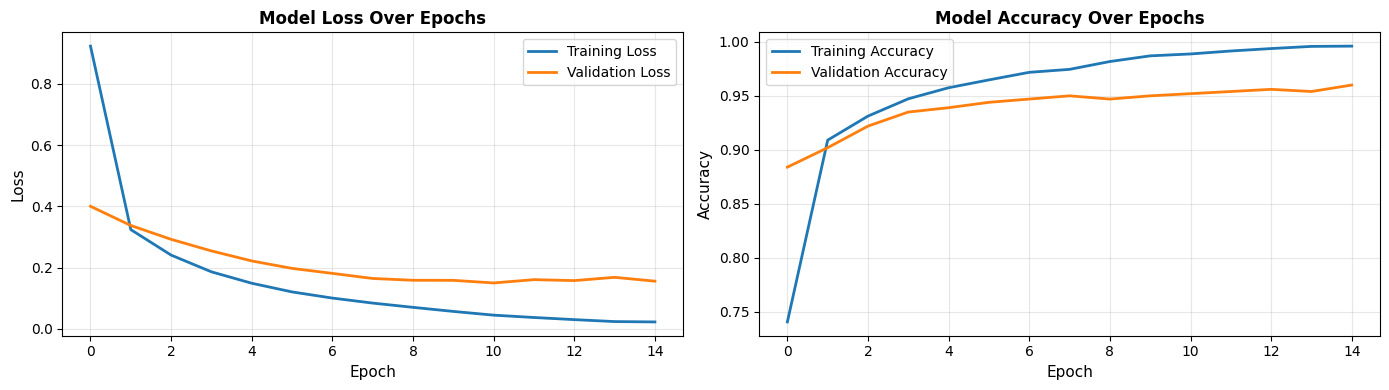

✓ Training history plotted


In [11]:
# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('keras_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Training history plotted")


VISUALIZING LEARNED FILTERS

First Conv Layer filter shape: (3, 3, 1, 4)
(height, width, input_channels, num_filters)


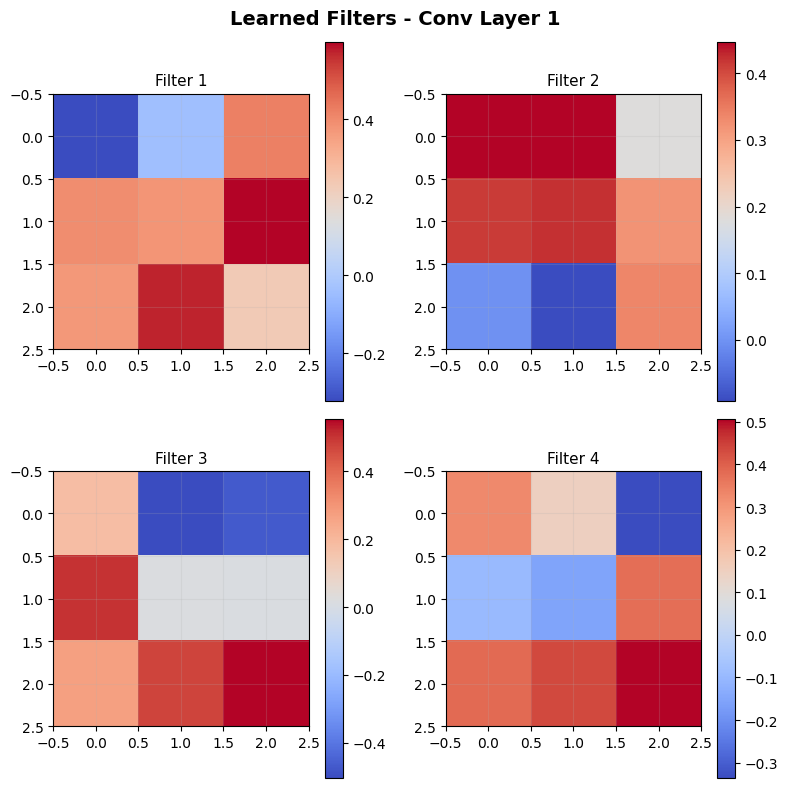

✓ Learned filters visualized


In [12]:
# Visualize learned filters from first convolutional layer
print("\n" + "=" * 60)
print("VISUALIZING LEARNED FILTERS")
print("=" * 60)

# Get weights from first conv layer
conv1_weights = model.layers[0].get_weights()[0]  # Shape: (3, 3, 1, 4)
print(f"\nFirst Conv Layer filter shape: {conv1_weights.shape}")
print("(height, width, input_channels, num_filters)")

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle('Learned Filters - Conv Layer 1', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # Extract one filter and squeeze the channel dimension
    filter_vis = conv1_weights[:, :, 0, i]
    im = ax.imshow(filter_vis, cmap='coolwarm')
    ax.set_title(f'Filter {i+1}', fontsize=11)
    ax.grid(True, alpha=0.2)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('learned_filters.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Learned filters visualized")

In [17]:
# Extract feature maps from intermediate layers
print("\n" + "=" * 60)
print("VISUALIZING FEATURE MAPS FROM TRAINED MODEL")
print("=" * 60)

# Process a test image
test_img = X_test_keras[0:1]  # Shape: (1, 28, 28, 1)

# Call the model on one sample to initialize input/output
_ = model(test_img)

# Create model that outputs intermediate layer activations
conv1_model = keras.Model(inputs=model.input, outputs=model.layers[0].output)
pool1_model = keras.Model(inputs=model.input, outputs=model.layers[2].output)
conv2_model = keras.Model(inputs=model.input, outputs=model.layers[3].output)
pool2_model = keras.Model(inputs=model.input, outputs=model.layers[5].output)

conv1_out = conv1_model.predict(test_img, verbose=0)
pool1_out = pool1_model.predict(test_img, verbose=0)
conv2_out = conv2_model.predict(test_img, verbose=0)
pool2_out = pool2_model.predict(test_img, verbose=0)

print(f"\nFeature map shapes for one test image:")
print(f"Conv1 output: {conv1_out.shape}")
print(f"Pool1 output: {pool1_out.shape}")
print(f"Conv2 output: {conv2_out.shape}")
print(f"Pool2 output: {pool2_out.shape}")

# Visualize
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.3)

# Input
ax = fig.add_subplot(gs[0, 0:2])
ax.imshow(test_img[0, :, :, 0], cmap='gray')
ax.set_title('Input Image (28x28)', fontsize=11, fontweight='bold')
ax.axis('off')

# Conv1 feature maps
for i in range(min(3, conv1_out.shape[3])):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(conv1_out[0, :, :, i], cmap='gray')
    ax.set_title(f'Conv1 FM {i+1}', fontsize=9)
    ax.axis('off')

# Pool1 feature maps
for i in range(min(3, pool1_out.shape[3])):
    ax = fig.add_subplot(gs[2, i])
    ax.imshow(pool1_out[0, :, :, i], cmap='gray')
    ax.set_title(f'Pool1 FM {i+1}', fontsize=9)
    ax.axis('off')

# Conv2 feature maps (show first 4)
for i in range(min(4, conv2_out.shape[3])):
    ax = fig.add_subplot(gs[3, i])
    ax.imshow(conv2_out[0, :, :, i], cmap='gray')
    ax.set_title(f'Conv2 FM {i+1}', fontsize=9)
    ax.axis('off')

plt.savefig('keras_feature_maps.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Feature maps visualized")



VISUALIZING FEATURE MAPS FROM TRAINED MODEL


NameError: name 'test_img' is not defined


MODEL PREDICTIONS


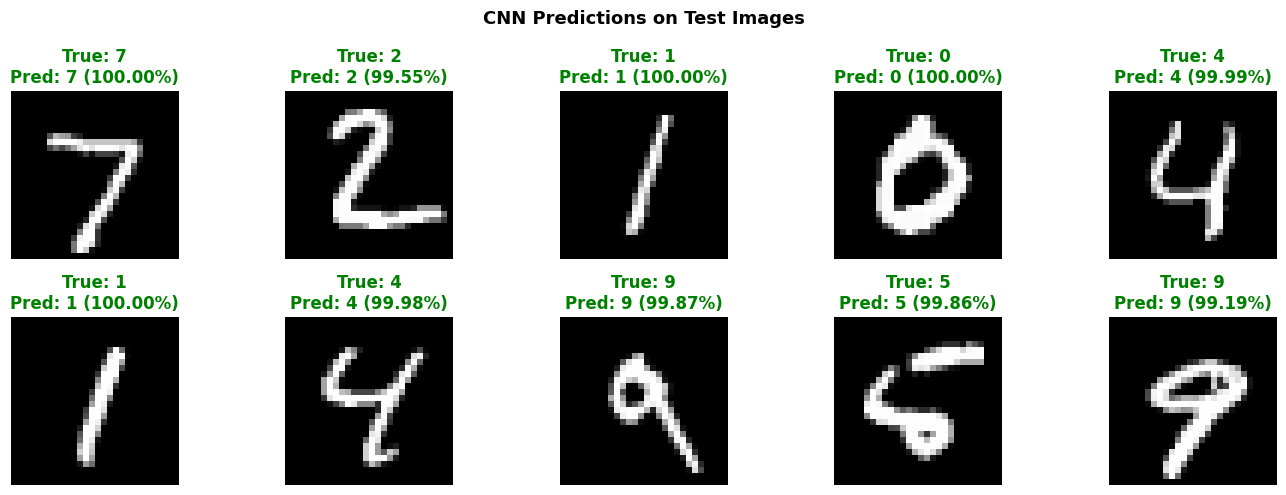

✓ Predictions visualized


In [14]:
print("\n" + "=" * 60)
print("MODEL PREDICTIONS")
print("=" * 60)

# Make predictions on test set
predictions = model.predict(X_test_keras, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

# Show some examples
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle('CNN Predictions on Test Images', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    idx = i
    true_label = y_test[idx]
    pred_label = predicted_classes[idx]
    confidence = predictions[idx, pred_label]
    
    ax.imshow(X_test[idx], cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2%})', 
                color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('cnn_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Predictions visualized")

## Part 7: Comparison - Manual vs Library Implementation

Let's compare what we learned from manual implementation with the library-based approach.


COMPARISON: MANUAL vs LIBRARY IMPLEMENTATION

               Aspect   Manual Implementation            TensorFlow/Keras
      Code Complexity    Complex (200+ lines)           Simple (10 lines)
Convolution Operation          ✓ Manual loops         ✓ Optimized kernels
      Filter Learning        ✗ Static weights        ✓ Automatic learning
        Backward Pass ✗ Manual implementation ✓ Automatic differentiation
          GPU Support                    ✗ No                       ✓ Yes
         Optimization      ✗ Manual gradients       ✓ Built-in optimizers
            Debugging   Easy (see every step)          Harder (black box)
        Customization      ✓ Complete control                  ◐ Moderate
          Performance                    Slow                        Fast
        Training Time               Very Slow                        Fast


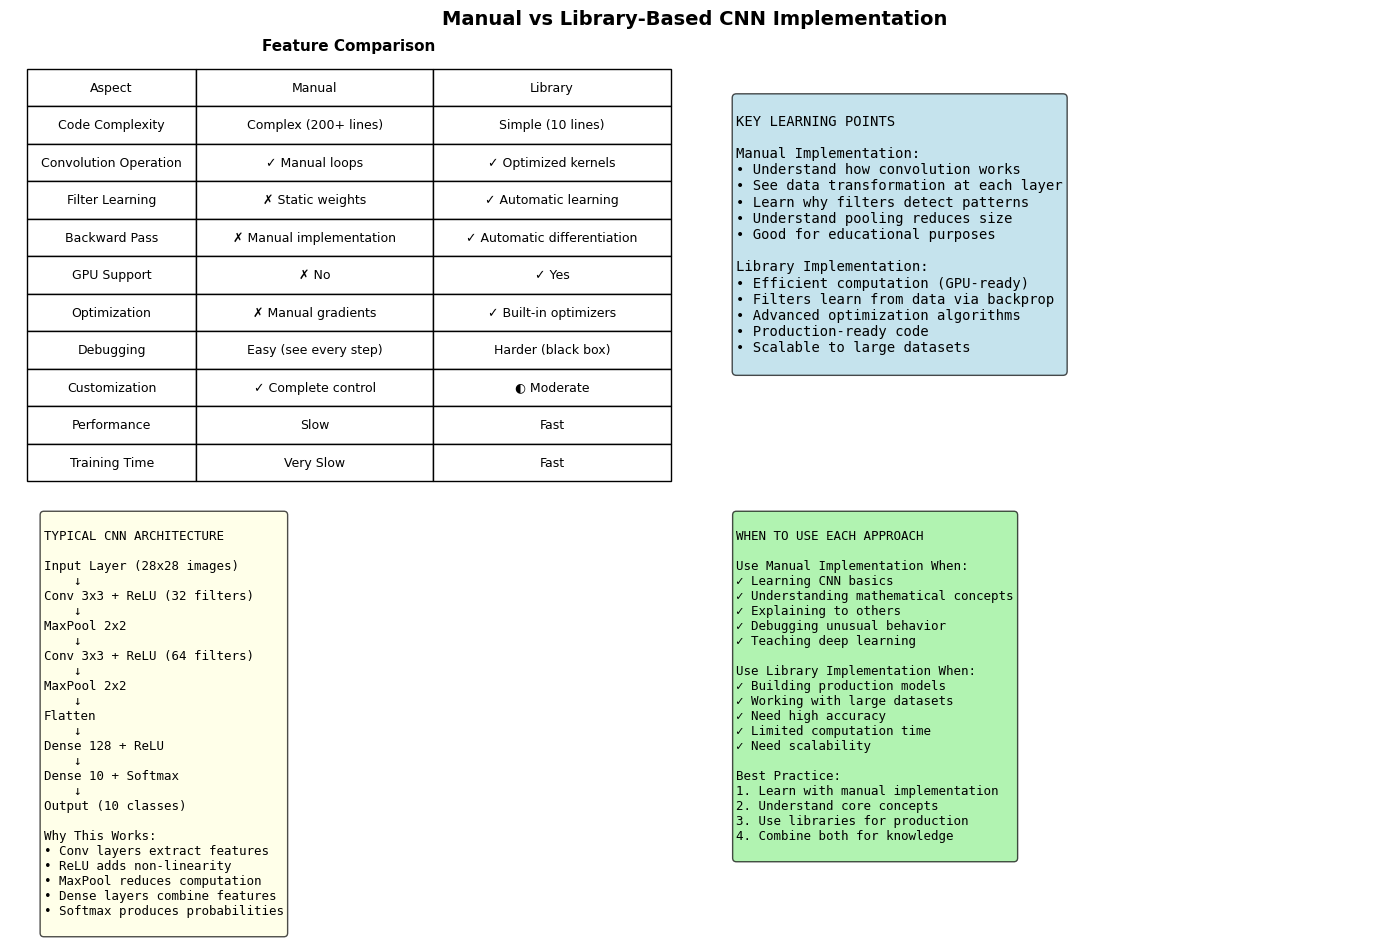


✓ Comparison completed


In [15]:
print("\n" + "=" * 60)
print("COMPARISON: MANUAL vs LIBRARY IMPLEMENTATION")
print("=" * 60)

comparison_data = {
    'Aspect': [
        'Code Complexity',
        'Convolution Operation',
        'Filter Learning',
        'Backward Pass',
        'GPU Support',
        'Optimization',
        'Debugging',
        'Customization',
        'Performance',
        'Training Time'
    ],
    'Manual Implementation': [
        'Complex (200+ lines)',
        '✓ Manual loops',
        '✗ Static weights',
        '✗ Manual implementation',
        '✗ No',
        '✗ Manual gradients',
        'Easy (see every step)',
        '✓ Complete control',
        'Slow',
        'Very Slow'
    ],
    'TensorFlow/Keras': [
        'Simple (10 lines)',
        '✓ Optimized kernels',
        '✓ Automatic learning',
        '✓ Automatic differentiation',
        '✓ Yes',
        '✓ Built-in optimizers',
        'Harder (black box)',
        '◐ Moderate',
        'Fast',
        'Fast'
    ]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Visualize the comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Manual vs Library-Based CNN Implementation', fontsize=14, fontweight='bold')

# Comparison table
ax = axes[0, 0]
ax.axis('off')
table_data = []
for idx, row in comparison_df.iterrows():
    table_data.append([row['Aspect'], row['Manual Implementation'], row['TensorFlow/Keras']])

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colLabels=['Aspect', 'Manual', 'Library'],
                colWidths=[0.25, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
ax.set_title('Feature Comparison', fontsize=11, fontweight='bold', pad=20)

# Key Learning Points
ax = axes[0, 1]
learning_points = """
KEY LEARNING POINTS

Manual Implementation:
• Understand how convolution works
• See data transformation at each layer
• Learn why filters detect patterns
• Understand pooling reduces size
• Good for educational purposes

Library Implementation:
• Efficient computation (GPU-ready)
• Filters learn from data via backprop
• Advanced optimization algorithms
• Production-ready code
• Scalable to large datasets
"""
ax.text(0.05, 0.95, learning_points, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax.axis('off')

# CNN Architecture Summary
ax = axes[1, 0]
arch_text = """
TYPICAL CNN ARCHITECTURE

Input Layer (28x28 images)
    ↓
Conv 3x3 + ReLU (32 filters)
    ↓
MaxPool 2x2
    ↓
Conv 3x3 + ReLU (64 filters)
    ↓
MaxPool 2x2
    ↓
Flatten
    ↓
Dense 128 + ReLU
    ↓
Dense 10 + Softmax
    ↓
Output (10 classes)

Why This Works:
• Conv layers extract features
• ReLU adds non-linearity
• MaxPool reduces computation
• Dense layers combine features
• Softmax produces probabilities
"""
ax.text(0.05, 0.95, arch_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
ax.axis('off')

# When to Use
ax = axes[1, 1]
usage_text = """
WHEN TO USE EACH APPROACH

Use Manual Implementation When:
✓ Learning CNN basics
✓ Understanding mathematical concepts
✓ Explaining to others
✓ Debugging unusual behavior
✓ Teaching deep learning

Use Library Implementation When:
✓ Building production models
✓ Working with large datasets
✓ Need high accuracy
✓ Limited computation time
✓ Need scalability

Best Practice:
1. Learn with manual implementation
2. Understand core concepts
3. Use libraries for production
4. Combine both for knowledge
"""
ax.text(0.05, 0.95, usage_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax.axis('off')

plt.tight_layout()
plt.savefig('manual_vs_library_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Comparison completed")

## Summary: CNN Learning Journey

### What You've Learned

1. **Convolution Operation** 🔄
   - How a filter slides across an image
   - Computing dot products creates feature maps
   - Each filter detects different patterns

2. **Filters & Feature Maps** 🎯
   - Multiple filters create multiple features
   - Early layers detect edges and textures
   - Later layers detect complex shapes

3. **Pooling Operations** 📉
   - Max pooling keeps strongest features
   - Average pooling smooths features
   - Reduces computation and parameters

4. **CNN Architecture** 🏗️
   - Conv → ReLU → Pool → (repeat) → Flatten → Dense
   - Why this structure works
   - Different variations (VGG, ResNet, etc.)

5. **Manual vs Library** ⚙️
   - Manual for understanding concepts
   - Libraries for production-ready code
   - Both are complementary

### Key Insights

| Concept | Why It Matters |
|---------|---|
| Local Connectivity | Uses far fewer parameters than fully connected layers |
| Parameter Sharing | Same filter finds features everywhere in image |
| Hierarchical Learning | Simple features → Complex concepts |
| Translation Invariance | Detects features regardless of position |

### Next Steps to Explore

1. **Advanced Architectures**: VGG, ResNet, Inception, DenseNet
2. **Transfer Learning**: Use pre-trained models on new tasks
3. **Object Detection**: Locate AND classify objects in images
4. **Semantic Segmentation**: Classify every pixel in image
5. **Visualization Techniques**: Grad-CAM, saliency maps
6. **Optimization**: Different optimizers, regularization, batch normalization

## Practical Exercise: Experiment with CNN Architecture

Try modifying the CNN architecture below and see how it affects accuracy!

In [16]:
print("\n" + "=" * 60)
print("EXERCISE: BUILD YOUR OWN CNN")
print("=" * 60)

# Try modifying these parameters!
EXPERIMENT_PARAMS = {
    'num_filters_1': 8,      # Try: 4, 8, 16, 32
    'num_filters_2': 16,     # Try: 8, 16, 32, 64
    'dense_units': 64,       # Try: 32, 64, 128, 256
    'dropout_rate': 0.0,     # Try: 0.0, 0.2, 0.5 (prevents overfitting)
    'epochs': 10,            # Try: 5, 10, 15, 20
}

print(f"\nCurrent parameters: {EXPERIMENT_PARAMS}")
print("\nTry modifying these and observe accuracy changes!")

# Build experimental model
experimental_model = keras.Sequential([
    layers.Conv2D(EXPERIMENT_PARAMS['num_filters_1'], (3, 3), padding='same', 
                  input_shape=(28, 28, 1)),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(EXPERIMENT_PARAMS['num_filters_2'], (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.Dropout(EXPERIMENT_PARAMS['dropout_rate']),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(EXPERIMENT_PARAMS['dense_units'], activation='relu'),
    layers.Dropout(EXPERIMENT_PARAMS['dropout_rate']),
    layers.Dense(10, activation='softmax')
])

experimental_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n" + "=" * 60)
print("EXPERIMENTAL MODEL ARCHITECTURE")
print("=" * 60)
experimental_model.summary()

# Quick training on subset
print("\nTraining experimental model (10 epochs)...")
exp_history = experimental_model.fit(
    X_train_keras[:2000], y_train_keras[:2000],
    epochs=EXPERIMENT_PARAMS['epochs'],
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

exp_test_loss, exp_test_accuracy = experimental_model.evaluate(X_test_keras, y_test_keras, verbose=0)
print(f"\nExperimental Model Test Accuracy: {exp_test_accuracy*100:.2f}%")
print(f"Original Model Test Accuracy: {test_accuracy*100:.2f}%")

# Compare accuracies
print("\n" + "=" * 60)
print("EXERCISE QUESTIONS")
print("=" * 60)
print("""
1. What happens if you increase num_filters_1 to 32?
   → More filters detect more features, but slower training

2. What happens if you add dropout_rate = 0.5?
   → Reduces overfitting, may reduce accuracy slightly

3. What's the trade-off between accuracy and speed?
   → More filters = higher accuracy but slower computation

4. Why does the model learn at all?
   → Backpropagation updates filters to minimize loss

Try it yourself! Modify EXPERIMENT_PARAMS and run again.
""")


EXERCISE: BUILD YOUR OWN CNN

Current parameters: {'num_filters_1': 8, 'num_filters_2': 16, 'dense_units': 64, 'dropout_rate': 0.0, 'epochs': 10}

Try modifying these and observe accuracy changes!

EXPERIMENTAL MODEL ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,138 (203.66 KB)

 Trainable params: 52,138 (203.66 KB)

 Non-trainable params: 0 (0.00 B)


Training experimental model (10 epochs)...
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5319 - loss: 1.6994 - val_accuracy: 0.7800 - val_loss: 0.7564
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8138 - loss: 0.6331 - val_accuracy: 0.8400 - val_loss: 0.4589
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8775 - loss: 0.4316 - val_accuracy: 0.8900 - val_loss: 0.3184
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9050 - loss: 0.3328 - val_accuracy: 0.9150 - val_loss: 0.2588
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9244 - loss: 0.2694 - val_accuracy: 0.9225 - val_loss: 0.2374
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9350 - loss: 0.2241 - val_accuracy: 0.9275 - val_loss: 0.2250
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9481 - loss: 0.1868 - val_accuracy: 0.9350 - val_loss: 0.2125
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9575 - los